---
# **2D Skeletonization**
## This is the .ipynb file for things that are related to 2D skeletonization. Most of the cells use .vtk files, but one directly uses the .nd2. Note that each of these cells can be run independently from one another.

Cooper Richman  
Professor Sang Hyun Lee  
University of Massachusetts Amherst Biofluids Lab  
25 February 2026  

---

## Change Log
2/25/2026: This file was created with parts of other files that have been collected in one area -C. Richman  
5/20/2026: I am tidying this up and getting it ready for the final repo



---

## **2D Skeletonization**

## Simpler skeletonizations with and without junctions and endpoints shown (sideways)

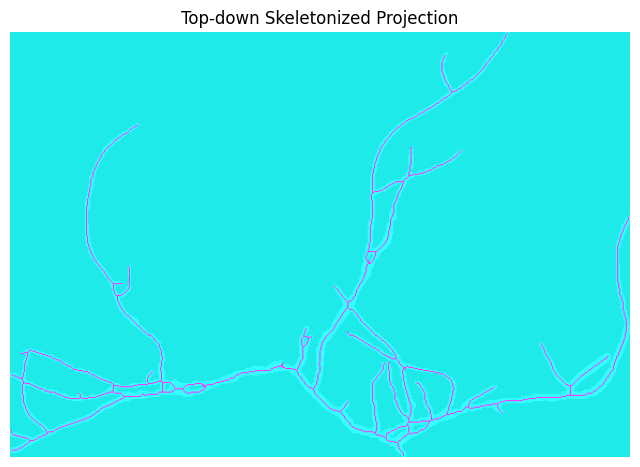

In [4]:
# Import several toolboxes to help
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import trimesh
from skimage.morphology import skeletonize

# --- Load the mesh ---
# Note that this should work with the current file structure, but the "mesh" variable is simply a filepath to the relevant .vtk file
mesh = pv.read(r"../../Data/Cleaned .vtk's/pos1_frame000016.vtk_cleaned_with_tol=1.5.vtk") # Note the double '..' in the file path to escape to the outside dir
# Export temporarily for trimesh
# Note that the "temp_mesh.stl" file will be overwritten on each run. To avoid this, simply change the name so that it saves to a different file
mesh.save("temp_mesh.stl")

# Load with trimesh
tmesh = trimesh.load("temp_mesh.stl")

# --- Voxelize ---
# Note that here (and everywhere else) pitch is referring to the size of the voxels that are being used
# This means larger pitch leads to larger voxels which leads to less detail captured
pitch = 1
voxels = tmesh.voxelized(pitch)

# Get 3D occupancy grid
grid = voxels.matrix  # shape: (nx, ny, nz)

# --- Collapse across Z (top-down projection) ---
collapsed = np.max(grid, axis=2)  # combine all z-layers
collapsed_binary = collapsed.astype(bool)  # ensure binary (0/1)

# --- Skeletonize 2D projection ---
skeleton = skeletonize(collapsed_binary)

# --- Display ---
plt.figure(figsize=(8, 8))
plt.imshow(collapsed_binary.T, origin='lower', cmap='gray', alpha=0.4)
plt.imshow(skeleton.T, origin='lower', cmap='cool', alpha=0.8)
plt.title("Top-down Skeletonized Projection")
plt.axis('off')
plt.show()


## After skeletonizing, add some dots to denote the tips and junctions

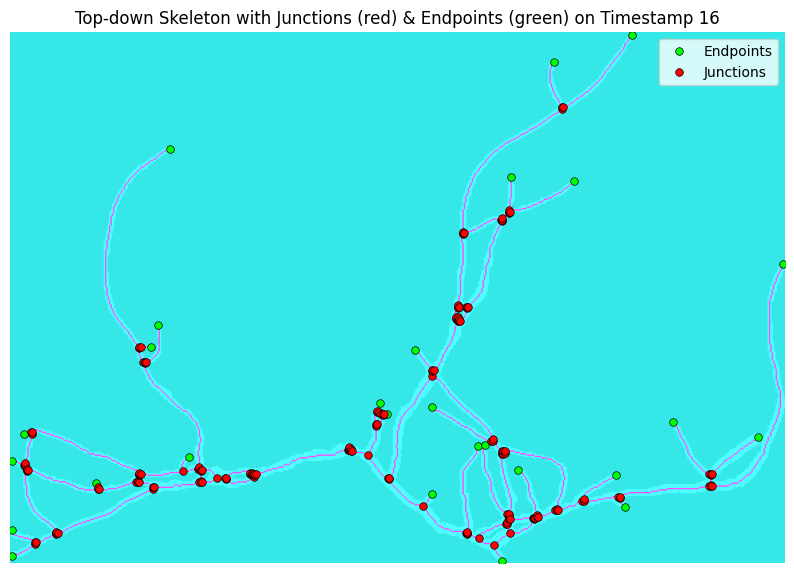

In [5]:
# Import several toolboxes to help
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import trimesh
from skimage.morphology import skeletonize
from scipy.ndimage import convolve

# --- Load the mesh ---
mesh = pv.read(r"../../Data/Cleaned .vtk's/pos1_frame000016.vtk_cleaned_with_tol=1.5.vtk") # Note the double '..' in the file path to escape to the outside dir

# Export temporarily for trimesh
mesh.save("temp_mesh.stl")

# Load with trimesh
tmesh = trimesh.load("temp_mesh.stl")

# --- Voxelize ---
pitch = 1
voxels = tmesh.voxelized(pitch)

# Get 3D occupancy grid
grid = voxels.matrix  # shape: (nx, ny, nz)

# --- Collapse across Z (top-down projection) ---
collapsed = np.max(grid, axis=2)
collapsed_binary = collapsed.astype(bool)

# --- Skeletonize ---
skeleton = skeletonize(collapsed_binary)

# --- Detect junctions and endpoints ---
# Define 3x3 neighborhood kernel (to count neighbors)
kernel = np.array([[1,1,1],
                   [1,0,1],
                   [1,1,1]])

# Convolution in this manner is a little too much to explain here, look up "2D convolution explanation" online for more
neighbor_count = convolve(skeleton.astype(int), kernel, mode='constant')

# Endpoints → skeleton pixels with only 1 neighbor
endpoints = (skeleton == 1) & (neighbor_count == 1)

# Junctions → skeleton pixels with 3 or more neighbors
junctions = (skeleton == 1) & (neighbor_count >= 3)

# --- Visualization ---
plt.figure(figsize=(10, 10))
plt.imshow(collapsed_binary.T, origin='lower', cmap='gray', alpha=0.3)
plt.imshow(skeleton.T, origin='lower', cmap='cool', alpha=0.7)

# Scatter plot of endpoints and junctions
ys, xs = np.nonzero(endpoints)
plt.scatter(ys, xs, c='lime', s=30, label='Endpoints', edgecolors='black', linewidths=0.5)

ys, xs = np.nonzero(junctions)
plt.scatter(ys, xs, c='red', s=30, label='Junctions', edgecolors='black', linewidths=0.5)

# The title below should be changed depending on the actual timepoint and dataset being graphed
plt.title("Top-down Skeleton with Junctions (red) & Endpoints (green) on Timestamp 16")
plt.axis('off')
plt.legend(loc='upper right', frameon=True)
plt.show()


## Now do it for all of the frames and save them
### This will allow you to complete skeletonization and tip/junction identification for each frame in a given dataset, and then save them. This is mostly useful for preliminary data and results, as the result is not very polished.

In [2]:
# Import several toolboxes to help
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import trimesh
from skimage.morphology import skeletonize
from scipy.ndimage import convolve
import os

# --- Parameters ---
# This is the input folder, to use a different dataset simply change the "input_dir" variable to be the folder that you want to do this with
# Note that the folder must contain the already created .vtk files
input_dir = r"..\..\Data\Raw .vtk's"

# --- Get all vtk files ---
vtk_files = sorted([
    f for f in os.listdir(input_dir)
    if f.endswith(".vtk")
])

pitch = 1

# Create output folder for plots (optional)
os.makedirs("skeleton_plots", exist_ok=True)

# --- Kernel for neighbor counting ---
kernel = np.array([[1, 1, 1],
                   [1, 0, 1],
                   [1, 1, 1]])

# --- Loop through files ---
for frame, filename in enumerate(vtk_files):

    filepath = os.path.join(input_dir, filename)

    if not os.path.exists(filepath):
        print(f"⚠️ Skipping missing file: {filepath}")
        continue

    print(f"Processing frame {frame}...")

    # --- Load the mesh ---
    mesh = pv.read(filepath)

    # Export temporarily for trimesh
    mesh.save("temp_mesh.stl")

    # Load with trimesh
    tmesh = trimesh.load("temp_mesh.stl")

    # --- Voxelize ---
    voxels = tmesh.voxelized(pitch)
    grid = voxels.matrix  # shape: (nx, ny, nz)

    # --- Collapse across Z (top-down projection) ---
    collapsed = np.max(grid, axis=2)
    collapsed_binary = collapsed.astype(bool)

    # --- Skeletonize ---
    skeleton = skeletonize(collapsed_binary)

    # --- Detect junctions and endpoints ---
    neighbor_count = convolve(skeleton.astype(int), kernel, mode='constant')
    endpoints = (skeleton == 1) & (neighbor_count == 1)
    junctions = (skeleton == 1) & (neighbor_count >= 3)

    # --- Visualization ---
    plt.figure(figsize=(10, 10))
    plt.imshow(collapsed_binary.T, origin='lower', cmap='gray', alpha=0.3)
    plt.imshow(skeleton.T, origin='lower', cmap='cool', alpha=0.7)

    # Scatter endpoints (green) and junctions (red)
    ys, xs = np.nonzero(endpoints)
    plt.scatter(ys, xs, c='lime', s=30, label='Endpoints', edgecolors='black', linewidths=0.5)

    ys, xs = np.nonzero(junctions)
    plt.scatter(ys, xs, c='red', s=30, label='Junctions', edgecolors='black', linewidths=0.5)

    plt.title(f"Top-down Skeleton with Junctions & Endpoints — Frame {frame}")
    plt.axis('off')
    plt.legend(loc='upper right', frameon=True)

    # --- Show or save plot ---
    # plt.show()  # Uncomment to display interactively
    plt.savefig(f"skeleton_plots/frame_{frame:02d}.png", bbox_inches='tight', dpi=200)
    plt.close()

print("✅ Finished processing all frames.")


Processing frame 0...
Processing frame 1...
Processing frame 2...
Processing frame 3...
Processing frame 4...
Processing frame 5...
Processing frame 6...
Processing frame 7...
Processing frame 8...
Processing frame 9...
Processing frame 10...
Processing frame 11...
Processing frame 12...
Processing frame 13...
Processing frame 14...
Processing frame 15...
✅ Finished processing all frames.


## Going from .ND2 to skeleton for original data
### This cell will generate a nice viewer that iterates over each frame of the growth with buttons in the bottom left.
### Note that this also shows an outline of the actual growth and then the skeleton overlayed. This can be toggled.

In [6]:
# Import several toolboxes to help
import numpy as np
import matplotlib
matplotlib.use("TkAgg")
import matplotlib.pyplot as plt

import tkinter as tk
from tkinter import ttk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

from nd2reader import ND2Reader
from skimage.morphology import skeletonize

# --------------------------
# CONFIG
# --------------------------
# This path can be easily changed to be another .nd2
# Note that the view index can also be changed (this can be seen in NISViewer too)
ND2_FILE = r"..\..\Data\.nd2 Files\ChannelFITC,TD_Seq0001-001.nd2"
VIEW_INDEX = 0   # use view 0 (series 0)
THRESH_FACTOR = 0.3   # threshold factor for making a binary mask

# --------------------------
# Collapse Z with MAX projection
# --------------------------
def collapse_z_max(frames_3d):
    """
    frames_3d: shape (Z, Y, X)
    returns (Y, X) max projection
    """
    return np.max(frames_3d, axis=0)

# --------------------------
# Center frame onto a common canvas
# --------------------------
def center_mask_on_canvas(mask, canvas_shape):
    ch, cw = canvas_shape
    h, w = mask.shape
    canvas = np.zeros((ch, cw), dtype=bool)

    start_y = (ch - h) // 2
    start_x = (cw - w) // 2

    dst_y0 = max(start_y, 0)
    dst_x0 = max(start_x, 0)
    dst_y1 = min(start_y + h, ch)
    dst_x1 = min(start_x + w, cw)

    src_y0 = max(0, -start_y)
    src_x0 = max(0, -start_x)
    src_y1 = src_y0 + (dst_y1 - dst_y0)
    src_x1 = src_x0 + (dst_x1 - dst_x0)

    if dst_y1 > dst_y0 and dst_x1 > dst_x0:
        canvas[dst_y0:dst_y1, dst_x0:dst_x1] = mask[src_y0:src_y1, src_x0:src_x1]

    return canvas

# --------------------------
# LOAD ND2 + extract view 0
# --------------------------
print("\nLoading ND2 file...")
nd2 = ND2Reader(ND2_FILE)
nd2.iter_axes = 't'     # iterate over time
nd2.bundle_axes = 'zyx' # load each timepoint as a stack (Z,Y,X)

print(f"File shape reported by nd2reader: {nd2.sizes}")

# Confirm view index exists
assert VIEW_INDEX == 0, "nd2reader automatically uses view 0 when using bundle_axes"

timepoints = nd2.sizes.get("t", 1)
print(f"Found {timepoints} timepoints\n")

collapsed_list = []

for t in range(timepoints):
    print(f"Reading timepoint {t+1}/{timepoints}...")
    stack = nd2.get_frame(t)     # shape (Z, Y, X)

    # Max projection
    collapsed = collapse_z_max(stack)

    # Normalize and threshold
    if collapsed.max() > 0:
        normed = collapsed / collapsed.max()
    else:
        normed = collapsed

    mask = normed > THRESH_FACTOR

    # Skeleton
    skel = skeletonize(mask)

    collapsed_list.append((mask, skel))

# Close the .nd2
nd2.close()
print("\nND2 loading done.\n")

# --------------------------
# Compute canvas size (largest frame)
# --------------------------
heights = [m.shape[0] for m, _ in collapsed_list]
widths = [m.shape[1] for m, _ in collapsed_list]
canvas_shape = (max(heights), max(widths))
print(f"Canvas size = {canvas_shape}")

# --------------------------
# Anchor each frame at top-left
# --------------------------
def paste_top_left(mask, canvas_shape):
    ch, cw = canvas_shape
    h, w = mask.shape
    canvas = np.zeros(canvas_shape, dtype=bool)
    canvas[0:h, 0:w] = mask
    return canvas

centered_masks = []
centered_skeletons = []

for mask, skel in collapsed_list:
    cm = paste_top_left(mask, canvas_shape)
    cs = skeletonize(cm)  # skeleton in aligned coordinates
    centered_masks.append(cm)
    centered_skeletons.append(cs)

print("Anchoring complete (top-left).")


# --------------------------
# Tkinter Viewer
# --------------------------
class SimpleViewer:
    def __init__(self, master, masks, skeletons):
        self.master = master
        self.masks = masks
        self.skeletons = skeletons
        self.N = len(masks)
        self.idx = 0

        master.protocol("WM_DELETE_WINDOW", self.on_close)
        master.title("ND2 Collapsed Skeleton Viewer")

        self.fig, self.ax = plt.subplots(figsize=(7, 7))
        self.canvas = FigureCanvasTkAgg(self.fig, master=master)
        self.canvas.get_tk_widget().pack(fill="both", expand=True)

        ctrl = tk.Frame(master)
        ctrl.pack(fill="x", pady=6)

        self.prev_btn = tk.Button(ctrl, text="<< Prev (Left)", command=self.prev_frame, width=14)
        self.prev_btn.pack(side="left", padx=6)

        self.next_btn = tk.Button(ctrl, text="Next >> (Right)", command=self.next_frame, width=14)
        self.next_btn.pack(side="left", padx=6)

        self.overlay_var = tk.IntVar(value=1)
        chk = tk.Checkbutton(ctrl, text="Show mask overlay", variable=self.overlay_var,
                             command=self.update_display)
        chk.pack(side="left", padx=12)

        self.frame_label = tk.Label(ctrl, text="")
        self.frame_label.pack(side="right", padx=10)

        master.bind("<Left>", lambda e: self.prev_frame())
        master.bind("<Right>", lambda e: self.next_frame())

        self.update_display()

    # Define some button presses and event handlers
    def on_close(self):
        plt.close("all")
        self.master.quit()
        self.master.destroy()

    def prev_frame(self):
        self.idx = (self.idx - 1) % self.N
        self.update_display()

    def next_frame(self):
        self.idx = (self.idx + 1) % self.N
        self.update_display()

    def update_display(self):
        self.ax.clear()
        sk = self.skeletons[self.idx]

        self.ax.imshow(sk, cmap="gray")

        if self.overlay_var.get() == 1:
            mk = self.masks[self.idx]
            self.ax.imshow(np.ma.masked_where(~mk, mk), cmap="Reds", alpha=0.3)

        self.ax.set_title(f"Timepoint {self.idx+1}/{self.N}")
        self.ax.axis("off")

        self.frame_label.config(text=f"Frame {self.idx+1}/{self.N}")
        self.canvas.draw()


# --------------------------
# Launch UI
# --------------------------
root = tk.Tk()
viewer = SimpleViewer(root, centered_masks, centered_skeletons)
root.mainloop()



Loading ND2 file...
File shape reported by nd2reader: {'x': 1024, 'y': 1024, 'c': 2, 't': 16, 'z': 117, 'v': 4}
Found 16 timepoints

Reading timepoint 1/16...
Reading timepoint 2/16...
Reading timepoint 3/16...
Reading timepoint 4/16...
Reading timepoint 5/16...
Reading timepoint 6/16...
Reading timepoint 7/16...
Reading timepoint 8/16...
Reading timepoint 9/16...
Reading timepoint 10/16...
Reading timepoint 11/16...
Reading timepoint 12/16...
Reading timepoint 13/16...
Reading timepoint 14/16...
Reading timepoint 15/16...
Reading timepoint 16/16...

ND2 loading done.

Canvas size = (1024, 1024)
Anchoring complete (top-left).
